- Name:Riyaan Chatterjee
- PRN: 23070126507
- Batch: AIML B3

GAN Assignment4

In [2]:
!pip install medmnist

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/87.2 kB ? eta -:--:--
     ---------------------------- ----------- 61.4/87.2 kB 1.6 MB/s eta 0:00:01
     ------------------------------------- -- 81.9/87.2 kB 1.5 MB/s eta 0:00:01
     ------------------------------------- -- 81.9/87.2 kB 1.5 MB/s eta 0:00:01
     -------------------------------------- 87.2/87.2 kB 545.7 kB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114263 sha256=19fea2bc76e773e9ff6c5cdeec92afd5002999a6b8f01e1e55848acfaa6772ce
  Stored in directory: c:\users\jmdgo\appdata\local\pip\cache\wheels\46\54\24\1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire



[notice] A new release of pip is available: 24.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
from torch.utils.tensorboard import SummaryWriter

In [6]:
# Load ChestMNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = ChestMNIST(split='train', transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

100%|█████████████████████████████████████████████████████████████████████████████| 82.8M/82.8M [00:50<00:00, 1.64MB/s]


In [8]:
# Define a simple CNN-based Generator
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Tanh()
        )
    
    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, 28, 28)
        return img

# Define CNN-based Discriminator for LS-GAN and WGAN
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
    
    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

# Initialize models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [10]:
# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Loss function for LS-GAN
criterion_ls = nn.MSELoss()

# TensorBoard Writer
writer = SummaryWriter()

def train_lsgan():
    for epoch in range(50):
        for i, (imgs, _) in enumerate(dataloader):
            imgs = imgs.to(device)
            batch_size = imgs.size(0)
            valid = torch.ones(batch_size, 1).to(device)
            fake = torch.zeros(batch_size, 1).to(device)
            
            # Train Generator
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, 100).to(device)
            gen_imgs = generator(z)
            g_loss = criterion_ls(discriminator(gen_imgs), valid)
            g_loss.backward()
            optimizer_G.step()
            
            # Train Discriminator
            optimizer_D.zero_grad()
            real_loss = criterion_ls(discriminator(imgs), valid)
            fake_loss = criterion_ls(discriminator(gen_imgs.detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()
            
        # Log losses and generated images
        writer.add_scalar("Loss/Generator", g_loss.item(), epoch)
        writer.add_scalar("Loss/Discriminator", d_loss.item(), epoch)
        
        with torch.no_grad():
            z = torch.randn(64, 100).to(device)
            gen_imgs = generator(z)
            writer.add_images('Generated Images', gen_imgs, epoch)
            vutils.save_image(gen_imgs, f'generated_epoch_{epoch}.png', normalize=True)

In [30]:
def train_wgan():
    for epoch in range(50):
        for i, (imgs, _) in enumerate(dataloader):
            imgs = imgs.to(device)
            batch_size = imgs.size(0)
            
            # Train Generator
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, 100).to(device)
            gen_imgs = generator(z)
            g_loss = -torch.mean(discriminator(gen_imgs))
            g_loss.backward()
            optimizer_G.step()
            
            # Train Discriminator
            optimizer_D.zero_grad()
            d_loss = torch.mean(discriminator(gen_imgs.detach())) - torch.mean(discriminator(imgs))
            d_loss.backward()
            optimizer_D.step()
            
            # Weight Clipping for WGAN
            for p in discriminator.parameters():
                p.data.clamp_(-0.01, 0.01)
        
        writer.add_scalar("Loss/Generator", g_loss.item(), epoch)
        writer.add_scalar("Loss/Discriminator", d_loss.item(), epoch)
        
        with torch.no_grad():
            z = torch.randn(64, 100).to(device)
            gen_imgs = generator(z)
            writer.add_images('Generated Images', gen_imgs, epoch)
            vutils.save_image(gen_imgs, f'generated_epoch_{epoch}.png', normalize=True)

In [37]:
def train_wgan_gp():
    lambda_gp = 10
    for epoch in range(50):
        for i, (imgs, _) in enumerate(dataloader):
            imgs = imgs.to(device)
            batch_size = imgs.size(0)
            
            # Train Generator
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, 100).to(device)
            gen_imgs = generator(z)
            g_loss = -torch.mean(discriminator(gen_imgs))
            g_loss.backward()
            optimizer_G.step()
            
            # Train Discriminator
            optimizer_D.zero_grad()
            alpha = torch.rand(batch_size, 1, 1, 1).to(device)
            interpolates = (alpha * imgs + (1 - alpha) * gen_imgs.detach()).requires_grad_(True)
            d_interpolates = discriminator(interpolates)
            gradients = torch.autograd.grad(outputs=d_interpolates, inputs=interpolates,
                                            grad_outputs=torch.ones_like(d_interpolates),
                                            create_graph=True, retain_graph=True)[0]
            gradient_penalty = lambda_gp * ((gradients.norm(2, dim=1) - 1) ** 2).mean()
            d_loss = torch.mean(discriminator(gen_imgs.detach())) - torch.mean(discriminator(imgs)) + gradient_penalty
            d_loss.backward()
            optimizer_D.step()
        
        writer.add_scalar("Loss/Generator", g_loss.item(), epoch)
        writer.add_scalar("Loss/Discriminator", d_loss.item(), epoch)
        
        with torch.no_grad():
            z = torch.randn(64, 100).to(device)
            gen_imgs = generator(z)
            writer.add_images('Generated Images', gen_imgs, epoch)
            vutils.save_image(gen_imgs, f'generated_epoch_{epoch}.png', normalize=True)

In [16]:
train_lsgan()

In [20]:
import os

log_dir = "C:/Users/jmdgo/Downloads/lsgan-epochs"
print("Log directory contents:", os.listdir(log_dir))

Log directory contents: ['events.out.tfevents.1743177778.5d1b67b5700f.31.0', 'generated_epoch_0.png', 'generated_epoch_1.png', 'generated_epoch_10.png', 'generated_epoch_11.png', 'generated_epoch_12.png', 'generated_epoch_13.png', 'generated_epoch_14.png', 'generated_epoch_15.png', 'generated_epoch_16.png', 'generated_epoch_17.png', 'generated_epoch_18.png', 'generated_epoch_19.png', 'generated_epoch_2.png', 'generated_epoch_20.png', 'generated_epoch_21.png', 'generated_epoch_22.png', 'generated_epoch_23.png', 'generated_epoch_24.png', 'generated_epoch_25.png', 'generated_epoch_26.png', 'generated_epoch_27.png', 'generated_epoch_28.png', 'generated_epoch_29.png', 'generated_epoch_3.png', 'generated_epoch_30.png', 'generated_epoch_31.png', 'generated_epoch_32.png', 'generated_epoch_33.png', 'generated_epoch_34.png', 'generated_epoch_35.png', 'generated_epoch_36.png', 'generated_epoch_37.png', 'generated_epoch_38.png', 'generated_epoch_39.png', 'generated_epoch_4.png', 'generated_epoch_4

In [24]:
%load_ext tensorboard

In [26]:
%tensorboard --logdir "C:/Users/jmdgo/Downloads/lsgan-epochs"

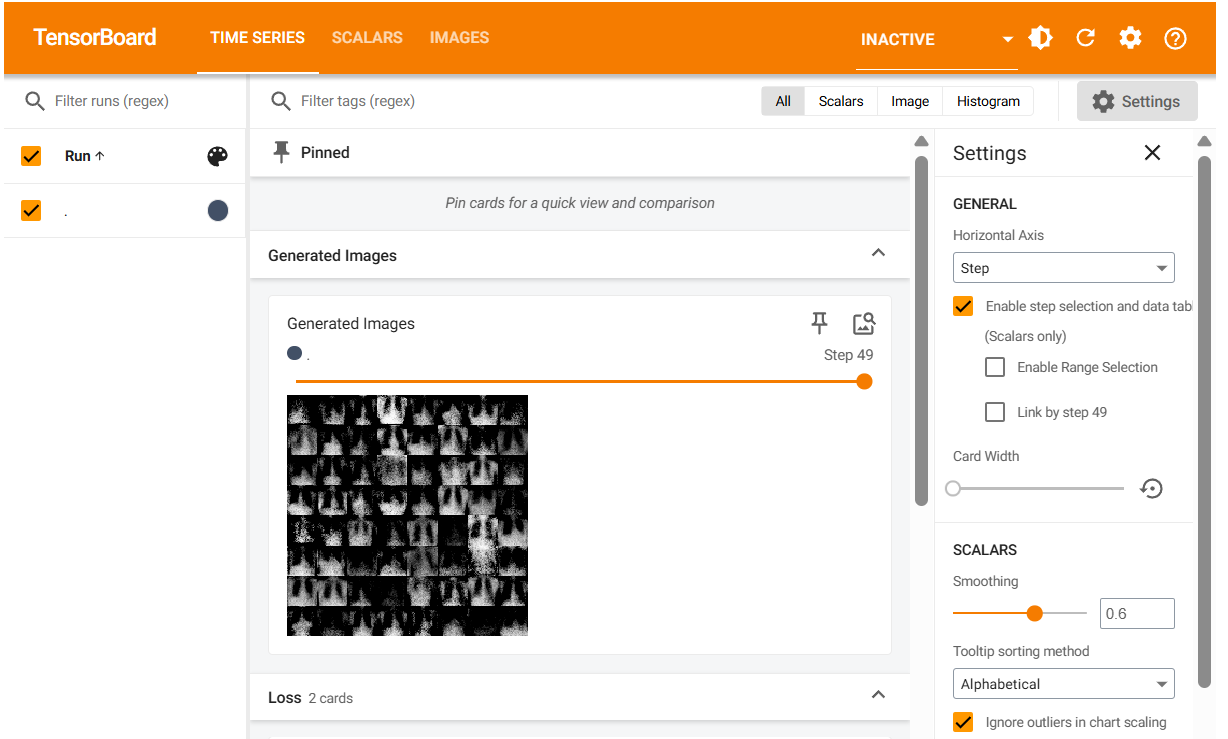

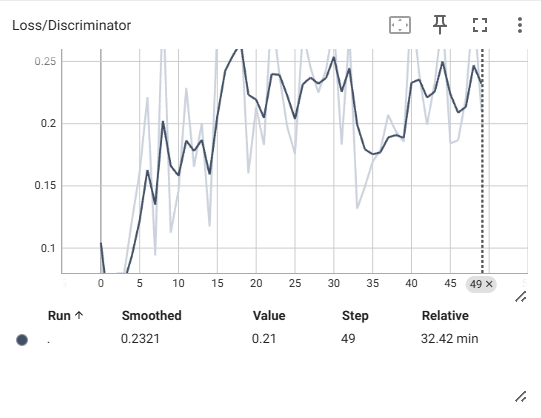

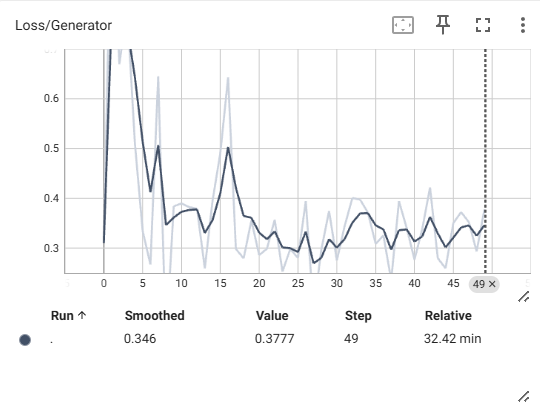

In [ ]:
train_wgan()

In [46]:
log_dir = "C:/Users/jmdgo/Downloads/wgan-epochs"
print("Log directory contents:", os.listdir(log_dir))

Log directory contents: ['events.out.tfevents.1743181093.DESKTOP-T6TE1HQ.420.0', 'gan-assignment-4.ipynb', 'generated_epoch_0.png', 'generated_epoch_1.png', 'generated_epoch_10.png', 'generated_epoch_11.png', 'generated_epoch_12.png', 'generated_epoch_13.png', 'generated_epoch_14.png', 'generated_epoch_15.png', 'generated_epoch_16.png', 'generated_epoch_17.png', 'generated_epoch_18.png', 'generated_epoch_19.png', 'generated_epoch_2.png', 'generated_epoch_20.png', 'generated_epoch_21.png', 'generated_epoch_22.png', 'generated_epoch_23.png', 'generated_epoch_24.png', 'generated_epoch_25.png', 'generated_epoch_26.png', 'generated_epoch_27.png', 'generated_epoch_28.png', 'generated_epoch_29.png', 'generated_epoch_3.png', 'generated_epoch_30.png', 'generated_epoch_31.png', 'generated_epoch_32.png', 'generated_epoch_33.png', 'generated_epoch_34.png', 'generated_epoch_35.png', 'generated_epoch_36.png', 'generated_epoch_37.png', 'generated_epoch_38.png', 'generated_epoch_39.png', 'generated_ep

In [33]:
%tensorboard --logdir "C:/Users/jmdgo/Downloads/wgan-epochs"

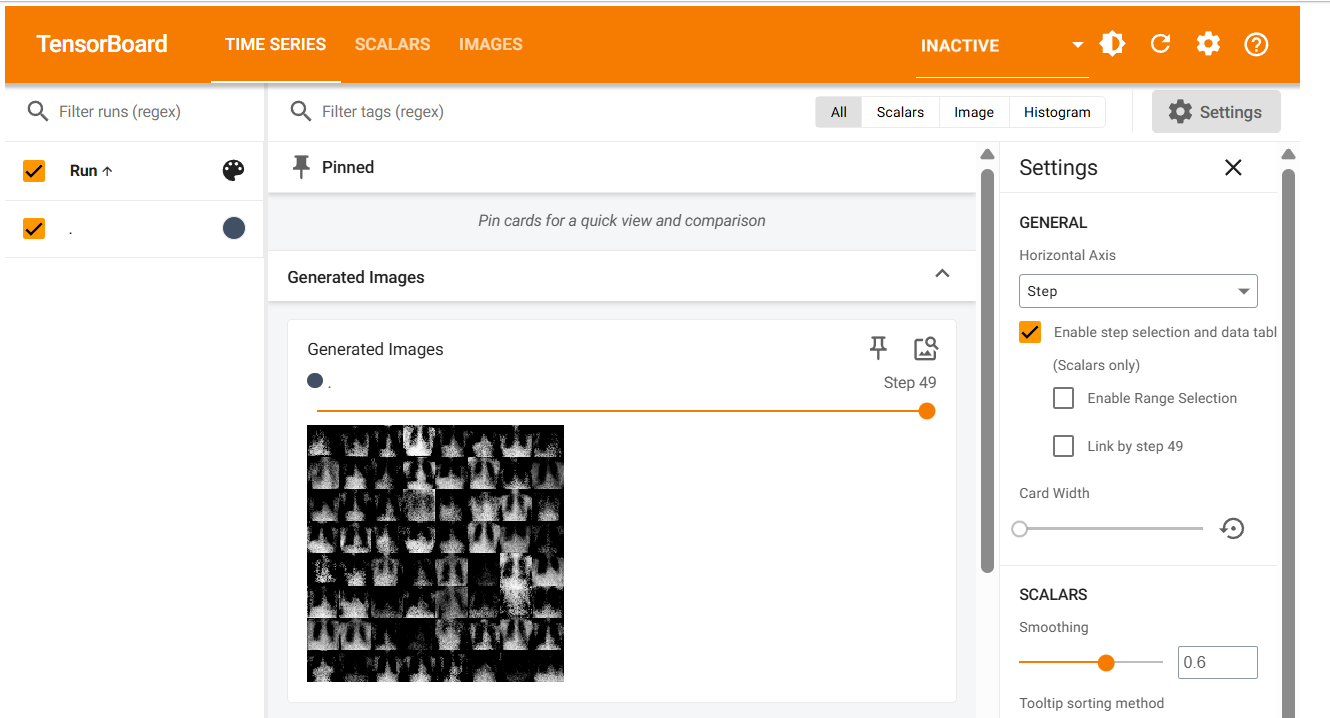

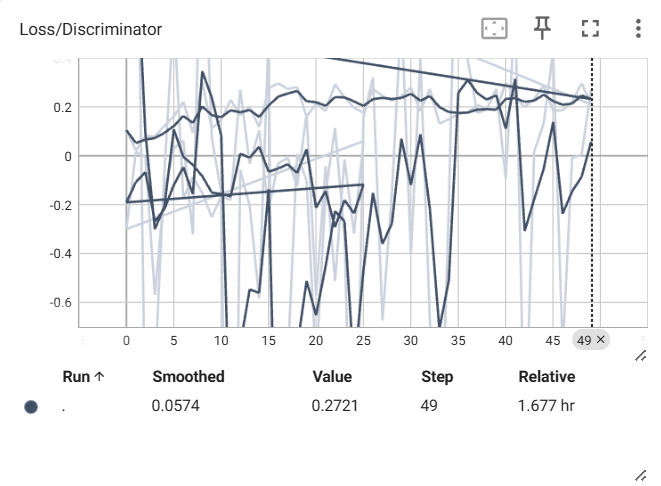

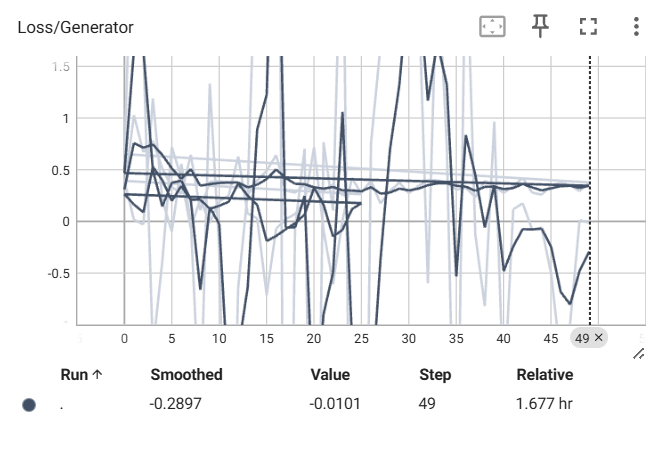

In [39]:
train_wgan_gp()

In [48]:
log_dir = "C:/Users/jmdgo/Downloads/wgan-gp-epochs"
print("Log directory contents:", os.listdir(log_dir))

Log directory contents: ['events.out.tfevents.1743181093.DESKTOP-T6TE1HQ.420.0', 'generated_epoch_0.png', 'generated_epoch_1.png', 'generated_epoch_10.png', 'generated_epoch_11.png', 'generated_epoch_12.png', 'generated_epoch_13.png', 'generated_epoch_14.png', 'generated_epoch_15.png', 'generated_epoch_16.png', 'generated_epoch_17.png', 'generated_epoch_18.png', 'generated_epoch_19.png', 'generated_epoch_2.png', 'generated_epoch_20.png', 'generated_epoch_21.png', 'generated_epoch_22.png', 'generated_epoch_23.png', 'generated_epoch_24.png', 'generated_epoch_25.png', 'generated_epoch_26.png', 'generated_epoch_27.png', 'generated_epoch_28.png', 'generated_epoch_29.png', 'generated_epoch_3.png', 'generated_epoch_30.png', 'generated_epoch_31.png', 'generated_epoch_32.png', 'generated_epoch_33.png', 'generated_epoch_34.png', 'generated_epoch_35.png', 'generated_epoch_36.png', 'generated_epoch_37.png', 'generated_epoch_38.png', 'generated_epoch_39.png', 'generated_epoch_4.png', 'generated_epo

In [41]:
%tensorboard --logdir "C:/Users/jmdgo/Downloads/wgan-gp-epochs"

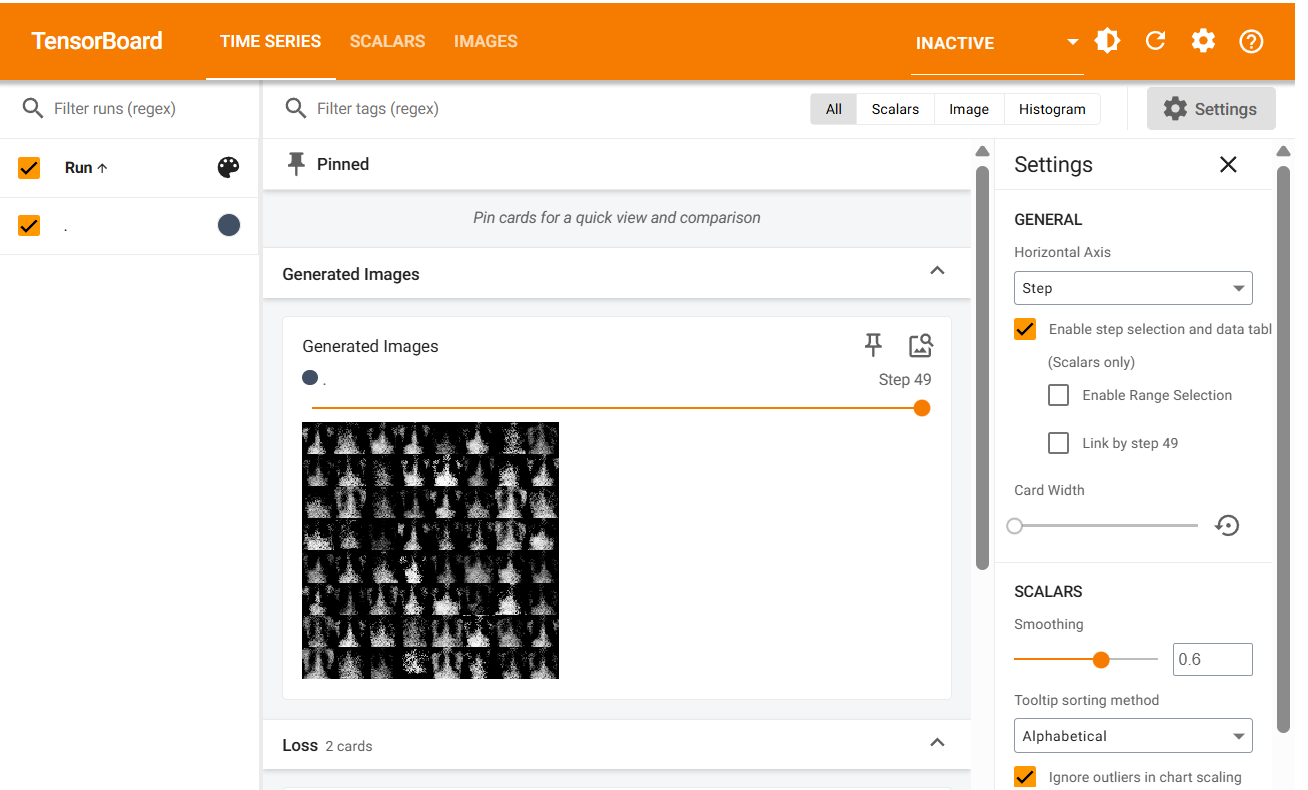

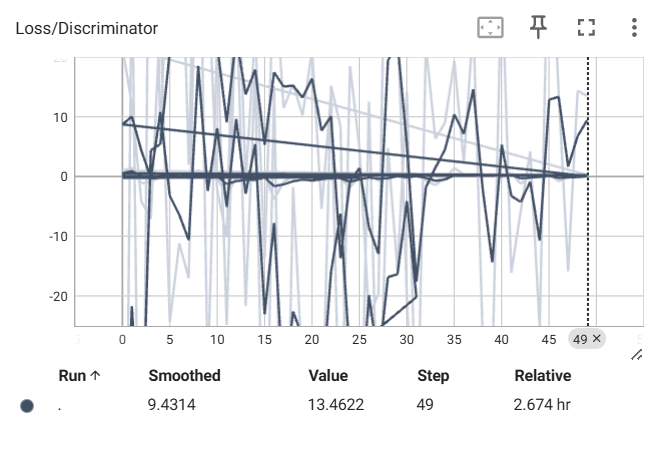

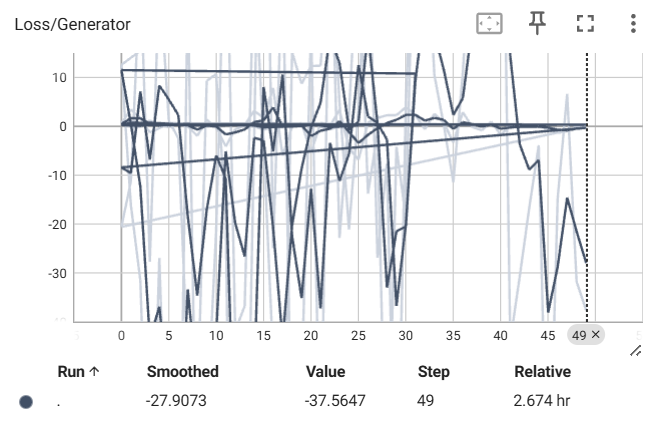

In [44]:
writer.close()